In [31]:
import torch
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from models.decoders import ReducedRankDecoder
from loader.base import SingleSessionDataModule
from utils.config import config_from_kwargs, update_config

### Latent space visualization

#### Gabors

In [18]:
base_path = "/burg/stats/users/yz4123/allen"

OUTPUT_SIZE_LOOKUP = {"gabors": 3, "static_gratings": 6}
LENGTH_LOOKUP = {"gabors": 0.2, "static_gratings": 0.2}

kwargs = {"model": f"include:{base_path.replace('allen', 'neural_decoding')}/src/configs/decoder.yaml"}
config = config_from_kwargs(kwargs)
config = update_config(f"{base_path.replace('allen', 'neural_decoding')}/src/configs/decoder.yaml", config)
config = update_config(f"{base_path.replace('allen', 'neural_decoding')}/src/configs/clf_trainer.yaml", config)

In [233]:
session_id = "721123822"
target = "gabors"
ckpt_name = "epoch=618-step=24760.ckpt"
best_model_path = Path(base_path)/"checkpoints"/session_id/target/"reduced_rank"/"all"/ckpt_name

config["session_id"] = session_id
config["target"] = target
config["length"] = LENGTH_LOOKUP[target]
config["model"]["output_size"] = OUTPUT_SIZE_LOOKUP[target]
config["region"] = "all"
config["training"]["device"] = torch.device("cpu")
config["dirs"]["data_dir"] = Path(base_path)/config.dirs.data_dir

In [234]:
# Load data
dm = SingleSessionDataModule(config)
dm.update_config()
dm.setup()
train_dataset, test_dataset = dm.train, dm.test

Loading cached data from /burg/stats/users/yz4123/allen/datasets/cached/721123822/gabors/all/val
Loading cached data from /burg/stats/users/yz4123/allen/datasets/cached/721123822/gabors/all/train
Loading cached data from /burg/stats/users/yz4123/allen/datasets/cached/721123822/gabors/all/val
Loading cached data from /burg/stats/users/yz4123/allen/datasets/cached/721123822/gabors/all/test


In [235]:
# Load model
model = ReducedRankDecoder.load_from_checkpoint(
    best_model_path,
    config=config
)

In [236]:
print(model.U.shape, model.V.shape)

torch.Size([444, 3]) torch.Size([3, 20, 3])


In [237]:
train_x, train_y = [], []
for (x, y, region, eid) in train_dataset:
    train_x.append(x)
    train_y.append(y)

test_x, test_y = [], []
for (x, y, region, eid) in test_dataset:
    test_x.append(x)
    test_y.append(y)

train_x, train_y = torch.stack(train_x), torch.stack(train_y)
test_x, test_y = torch.stack(test_x), torch.stack(test_y)

print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)

torch.Size([2550, 20, 444]) torch.Size([2550])
torch.Size([729, 20, 444]) torch.Size([729])


In [238]:
latents = ((test_x @ model.U) * model.V.mean(-1).T.unsqueeze(0)).detach().numpy()[:50]
# latents = (test_x @ model.U).detach().numpy()[:50]
labels = test_y.numpy()[:50]
print(latents.shape)
print(latents.shape)

(50, 20, 3)
(50, 20, 3)


In [239]:
from scipy.ndimage import gaussian_filter1d
sigma = 3.0
smoothed_latents = np.zeros_like(latents)

for i in range(latents.shape[0]):
    for j in range(latents.shape[-1]):
        smoothed_latents[i, :, j] = gaussian_filter1d(latents[i, :, j], sigma=sigma)


/local/ipykernel_3302364/790199961.py:46: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(f"{base_path.replace('allen', 'neural_decoding')}/notebooks/figs/latents_{target}.png", dpi=300)
/local/ipykernel_3302364/790199961.py:46: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(f"{base_path.replace('allen', 'neural_decoding')}/notebooks/figs/latents_{target}.png", dpi=300)
/local/ipykernel_3302364/790199961.py:46: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(f"{base_path.replace('allen', 'neural_decoding')}/notebooks/figs/latents_{target}.png", dpi=300)
/local/ipykernel_330

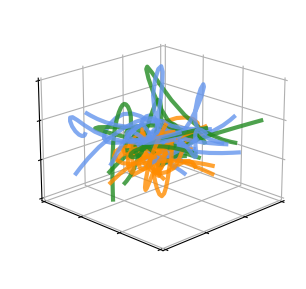

In [240]:
# COLOR = ["red", "blue", "green"]
COLOR = ['cornflowerblue', 'forestgreen', 'darkorange', 'lightgray', 'tab:brown', 'mediumpurple']

fig = plt.figure(figsize=(3, 4))
ax = fig.add_subplot(111, projection='3d')

# Make panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

for i, latent in enumerate(smoothed_latents):
    scatter = ax.plot3D(
        latent[...,0], latent[...,1], latent[...,2], color=COLOR[labels[i]], alpha=.8, linewidth=3.
    )

ax.view_init(elev=20, azim=45)

x_min, x_max = -0.008, 0.007
y_min, y_max = -0.008, 0.007
z_min, z_max = -0.0075, 0.0085
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)

x_ticks = np.linspace(x_min, x_max, 4)
y_ticks = np.linspace(y_min, y_max, 4)
z_ticks = np.linspace(z_min, z_max, 4)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_zticks(z_ticks)

# ax.set_xticklabels([f'{x:.2}' for x in x_ticks])
# ax.set_yticklabels([f'{x:.2}' for x in y_ticks])
# ax.set_zticklabels([f'{x:.2}' for x in z_ticks])

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

# ax.set_xlabel('Rank 1')
# ax.set_ylabel('Rank 2')
# ax.set_zlabel('Rank 3')

plt.tight_layout()
plt.savefig(f"{base_path.replace('allen', 'neural_decoding')}/notebooks/figs/latents_{target}.png", dpi=300)
plt.show()

#### Static Gratings

In [221]:
base_path = "/burg/stats/users/yz4123/allen"

OUTPUT_SIZE_LOOKUP = {"gabors": 3, "static_gratings": 6}
LENGTH_LOOKUP = {"gabors": 0.2, "static_gratings": 0.2}

kwargs = {"model": f"include:{base_path.replace('allen', 'neural_decoding')}/src/configs/decoder.yaml"}
config = config_from_kwargs(kwargs)
config = update_config(f"{base_path.replace('allen', 'neural_decoding')}/src/configs/decoder.yaml", config)
config = update_config(f"{base_path.replace('allen', 'neural_decoding')}/src/configs/clf_trainer.yaml", config)

In [241]:
session_id = "721123822"
target = "static_gratings"
ckpt_name = "epoch=140-step=9024.ckpt"
best_model_path = Path(base_path)/"checkpoints"/session_id/target/"reduced_rank"/"all"/ckpt_name

config["session_id"] = session_id
config["target"] = target
config["length"] = LENGTH_LOOKUP[target]
config["model"]["output_size"] = OUTPUT_SIZE_LOOKUP[target]
config["region"] = "all"
config["training"]["device"] = torch.device("cpu")
config["dirs"]["data_dir"] = Path(base_path)/config.dirs.data_dir

In [242]:
# Load data
dm = SingleSessionDataModule(config)
dm.update_config()
dm.setup()
train_dataset, test_dataset = dm.train, dm.test

Loading cached data from /burg/stats/users/yz4123/allen/datasets/cached/721123822/static_gratings/all/val
Loading cached data from /burg/stats/users/yz4123/allen/datasets/cached/721123822/static_gratings/all/train
Loading cached data from /burg/stats/users/yz4123/allen/datasets/cached/721123822/static_gratings/all/val
Loading cached data from /burg/stats/users/yz4123/allen/datasets/cached/721123822/static_gratings/all/test


In [243]:
# Load model
model = ReducedRankDecoder.load_from_checkpoint(
    best_model_path,
    config=config
)

In [244]:
print(model.U.shape, model.V.shape)

torch.Size([444, 3]) torch.Size([3, 20, 6])


In [245]:
train_x, train_y = [], []
for (x, y, region, eid) in train_dataset:
    train_x.append(x)
    train_y.append(y)

test_x, test_y = [], []
for (x, y, region, eid) in test_dataset:
    test_x.append(x)
    test_y.append(y)

train_x, train_y = torch.stack(train_x), torch.stack(train_y)
test_x, test_y = torch.stack(test_x), torch.stack(test_y)

print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)

torch.Size([4061, 20, 444]) torch.Size([4061])
torch.Size([1160, 20, 444]) torch.Size([1160])


In [246]:
latents = ((test_x @ model.U) * model.V.mean(-1).T.unsqueeze(0)).detach().numpy()[:50]
# latents = (test_x @ model.U).detach().numpy()[:50]
labels = test_y.numpy()[:50]
print(latents.shape)
print(latents.shape)

(50, 20, 3)
(50, 20, 3)


In [247]:
from scipy.ndimage import gaussian_filter1d
sigma = 2
smoothed_latents = np.zeros_like(latents)

for i in range(latents.shape[0]):
    for j in range(latents.shape[-1]):
        smoothed_latents[i, :, j] = gaussian_filter1d(latents[i, :, j], sigma=sigma)


/local/ipykernel_3302364/3505470370.py:46: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(f"{base_path.replace('allen', 'neural_decoding')}/notebooks/figs/latents_{target}.png", dpi=300)
/local/ipykernel_3302364/3505470370.py:46: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(f"{base_path.replace('allen', 'neural_decoding')}/notebooks/figs/latents_{target}.png", dpi=300)
/local/ipykernel_3302364/3505470370.py:46: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(f"{base_path.replace('allen', 'neural_decoding')}/notebooks/figs/latents_{target}.png", dpi=300)
/local/ipykernel_

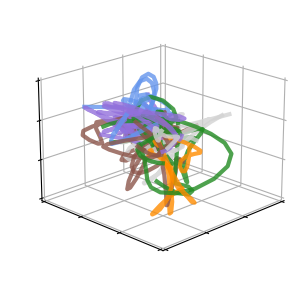

In [248]:
# COLOR = ["red", "blue", "green", "orange", "purple", "pink"]
COLOR = ['cornflowerblue', 'forestgreen', 'darkorange', 'lightgray', 'tab:brown', 'mediumpurple']

fig = plt.figure(figsize=(3, 4))
ax = fig.add_subplot(111, projection='3d')

# Make panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

for i, latent in enumerate(smoothed_latents):
    scatter = ax.plot3D(
        latent[...,0], latent[...,1], latent[...,2], color=COLOR[labels[i]], alpha=.8, linewidth=3.
    )

ax.view_init(elev=20, azim=45)

x_min, x_max = -0.014, 0.0052
y_min, y_max = -0.036, 0.016
z_min, z_max = -0.012, 0.0056
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)

x_ticks = np.linspace(x_min, x_max, 4)
y_ticks = np.linspace(y_min, y_max, 4)
z_ticks = np.linspace(z_min, z_max, 4)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_zticks(z_ticks)

# ax.set_xticklabels([f'{x:.2}' for x in x_ticks])
# ax.set_yticklabels([f'{x:.2}' for x in y_ticks])
# ax.set_zticklabels([f'{x:.2}' for x in z_ticks])

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

# ax.set_xlabel('Rank 1')
# ax.set_ylabel('Rank 2')
# ax.set_zlabel('Rank 3')

plt.tight_layout()
# plt.savefig(f"{base_path.replace('allen', 'neural_decoding')}/notebooks/figs/latents_{target}.png", dpi=300)
plt.show()

### Behavior visualization

### BMM-HMM visualization